# Exercise: Exploration Strategies
## AIAT 123 - Reinforcement Learning

## Learning Objectives
- Implement epsilon-greedy strategy
- Implement UCB algorithm
- Compare exploration strategies
- Apply to A/B testing

## Real-World Context
You're optimizing ad placement for an e-commerce platform.

## Exercise Brief

This exercise checks whether students can compare exploration strategies in a structured way.

They should not only run the code, but also explain why different strategies behave differently.

Why this matters: Unit 4 is about judgment and interpretation, not only implementation.

This exercise is meant to make students defend what they observe.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Exercise Goal

In this exercise, you will build a small bandit setup and compare exploration
strategies using reward and regret, not just raw code.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


### Step Guide

**What this cell does:** Install or import dependencies so later cells can run.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Pip progress lines and usually a confirmation that imports work.

**If you feel lost:** Fix any red install error before continuing—later cells assume this cell succeeded.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install numpy matplotlib -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: Multi-Armed Bandit (20 points)

Simulate a multi-armed bandit with different ad CTRs.

### Step Guide

**What this cell does:** Follow the printed section: "Bandit ready with"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `MultiArmedBandit` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class MultiArmedBandit:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, n_arms, true_rewards.
    def __init__(self, n_arms, true_rewards):
        # Save a value in a name so the next lines can read it.
        self.n_arms = n_arms
        # Another assignment—same idea: store a value for the lines below.
        self.true_rewards = np.asarray(true_rewards, dtype=float)

    # Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, arm.
    def pull(self, arm):
        # Send a value back to whoever called this function.
        return float(np.random.binomial(1, self.true_rewards[arm]))


# Save a value in a name so the next lines can read it.
bandit = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
# Show text or numbers in the cell output area under the code.
print("Bandit ready with", bandit.n_arms, "arms")
# Show text or numbers in the cell output area under the code.
print("Task 1 prompt: explain why the true rewards are hidden from the agent.")


Bandit ready with 4 arms
Task 1 prompt: explain why the true rewards are hidden from the agent.


## Task 2: Epsilon-Greedy (25 points)

Implement epsilon-greedy exploration strategy.

### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: bandit, epsilon, n_steps.
def epsilon_greedy(bandit, epsilon=0.1, n_steps=1000):
    # Save a value in a name so the next lines can read it.
    q = np.zeros(bandit.n_arms)
    # Another assignment—same idea: store a value for the lines below.
    n = np.zeros(bandit.n_arms)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Save a value in a name so the next lines can read it.
    chosen_actions = []

    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(n_steps):
        # If the condition is True, run the indented block under this line.
        if np.random.rand() < epsilon:
            # Save a value in a name so the next lines can read it.
            action = np.random.randint(bandit.n_arms)
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            action = int(np.argmax(q))
        # Unpack the one-step model output from transition(state, action).
        reward = bandit.pull(action)
        # Save a value in a name so the next lines can read it.
        n[action] += 1
        # Another assignment—same idea: store a value for the lines below.
        q[action] += (reward - q[action]) / n[action]
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
        # Add one new item to the end of a list (the list grows in place).
        chosen_actions.append(action)

    # Send a value back to whoever called this function.
    return q, np.array(rewards), np.array(chosen_actions)


# Save a value in a name so the next lines can read it.
q_eg, rewards_eg, actions_eg = epsilon_greedy(bandit, epsilon=0.1, n_steps=500)
# Show text or numbers in the cell output area under the code.
print("epsilon-greedy estimated values:", np.round(q_eg, 3))


epsilon-greedy estimated values: [0.167 0.194 0.25  0.18 ]


## Task 3: UCB Algorithm (30 points)

Implement Upper Confidence Bound algorithm.

### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: bandit, c, n_steps.
def ucb(bandit, c=2.0, n_steps=1000):
    # Save a value in a name so the next lines can read it.
    q = np.zeros(bandit.n_arms)
    # Another assignment—same idea: store a value for the lines below.
    n = np.zeros(bandit.n_arms)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Save a value in a name so the next lines can read it.
    chosen_actions = []

    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(1, n_steps + 1):
        # Save a value in a name so the next lines can read it.
        exploration_bonus = np.full(bandit.n_arms, np.inf)
        # Another assignment—same idea: store a value for the lines below.
        tried = n > 0
        # Another assignment—same idea: store a value for the lines below.
        exploration_bonus[tried] = c * np.sqrt(np.log(t + 1) / n[tried])
        # Another assignment—same idea: store a value for the lines below.
        action = int(np.argmax(q + exploration_bonus))
        # Unpack the one-step model output from transition(state, action).
        reward = bandit.pull(action)
        # Save a value in a name so the next lines can read it.
        n[action] += 1
        # Another assignment—same idea: store a value for the lines below.
        q[action] += (reward - q[action]) / n[action]
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
        # Add one new item to the end of a list (the list grows in place).
        chosen_actions.append(action)

    # Send a value back to whoever called this function.
    return q, np.array(rewards), np.array(chosen_actions)


# Save a value in a name so the next lines can read it.
bandit_ucb = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
# Another assignment—same idea: store a value for the lines below.
q_ucb, rewards_ucb, actions_ucb = ucb(bandit_ucb, c=2.0, n_steps=500)
# Show text or numbers in the cell output area under the code.
print("UCB estimated values:", np.round(q_ucb, 3))


UCB estimated values: [0.088 0.242 0.345 0.196]


## Task 4: Comparison (25 points)

Compare strategies and analyze results.

### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


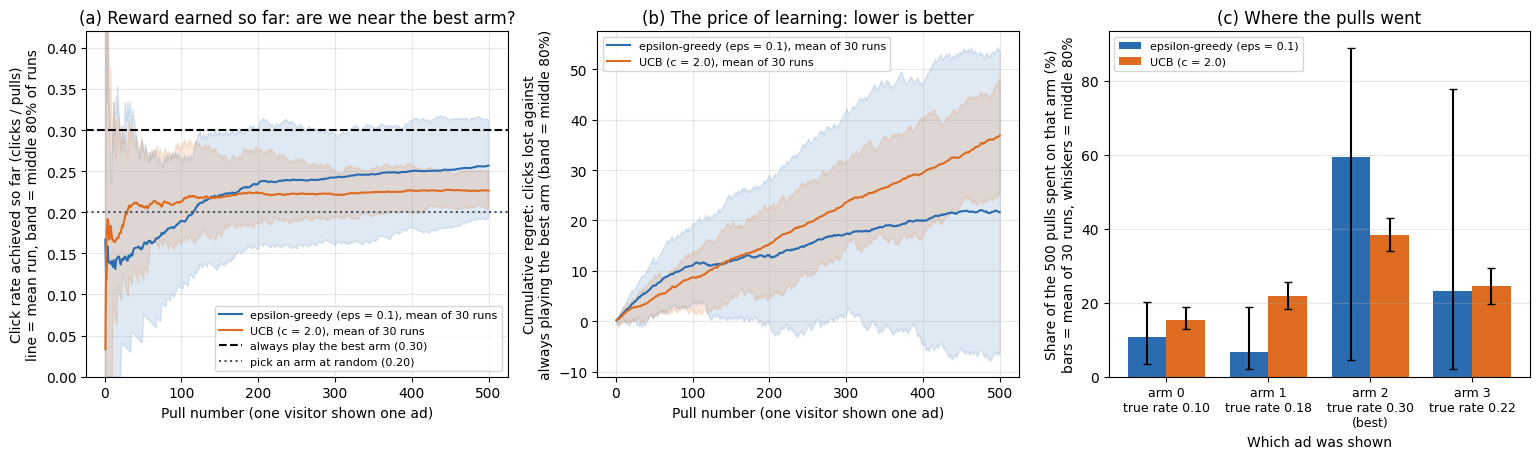

epsilon-greedy (eps = 0.1)   | final regret  21.60 +/- 20.89 | pulls on the best arm  59.3% | worst of the 30 runs: regret  65.00
UCB (c = 2.0)                | final regret  36.83 +/- 9.87 | pulls on the best arm  38.2% | worst of the 30 runs: regret  65.00

Reflection prompts:
1. Which strategy found the best arm faster?
2. Which strategy accumulated less regret?
3. Why might UCB outperform epsilon-greedy in this setup?
4. Look at the shaded bands and the whiskers: could a SINGLE run have told you the opposite story?
5. Prompt 3 asks why UCB MIGHT outperform. Check the printed regret first - does it, here, at 500
   pulls with c = 2.0 on arms that pay only 0.10 to 0.30? What would you change to give UCB its edge?


In [5]:
# Task 4: compare the two strategies HONESTLY - by repeating the whole experiment, not by running it once.
# One 500-step run of a random bandit is a coin flip: either strategy can look better by luck.
# So we repeat each strategy 30 times with different random streams and plot the average run,
# with a shaded band showing how much individual runs disagree.

# Turn a stream of 0/1 rewards into "average reward up to this step".
def cumulative_average(rewards):
    # Send a value back to whoever called this function.
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)


# Regret = what the BEST arm would have paid, minus what we actually collected, added up over time.
def cumulative_regret(true_best_reward, rewards):
    # Send a value back to whoever called this function.
    return np.cumsum(true_best_reward - rewards)


N_RUNS, N_STEPS = 30, 500
# The best arm's true click rate - the ceiling no strategy can beat on average.
best_possible = float(np.max(bandit.true_rewards))
best_arm = int(np.argmax(bandit.true_rewards))
# What a strategy that just picks uniformly at random would earn: the average of all four arms.
random_baseline = float(np.mean(bandit.true_rewards))

# Collect one row per repeat, for each strategy.
results = {}
for name in ("epsilon-greedy (eps = 0.1)", "UCB (c = 2.0)"):
    avg_curves, regret_curves, pull_shares = [], [], []
    for run in range(N_RUNS):
        # A different seed per repeat: the randomness is real, but the whole figure still reproduces.
        np.random.seed(1000 + run)
        fresh_bandit = MultiArmedBandit(bandit.n_arms, bandit.true_rewards)
        if name.startswith("epsilon"):
            _, run_rewards, run_actions = epsilon_greedy(fresh_bandit, epsilon=0.1, n_steps=N_STEPS)
        else:
            _, run_rewards, run_actions = ucb(fresh_bandit, c=2.0, n_steps=N_STEPS)
        avg_curves.append(cumulative_average(run_rewards))
        regret_curves.append(cumulative_regret(best_possible, run_rewards))
        pull_shares.append(np.bincount(run_actions, minlength=bandit.n_arms) / N_STEPS)
    results[name] = {
        "avg": np.array(avg_curves),
        "regret": np.array(regret_curves),
        "shares": np.array(pull_shares),
    }

steps = np.arange(1, N_STEPS + 1)
colors = {"epsilon-greedy (eps = 0.1)": "#2b6cb0", "UCB (c = 2.0)": "#dd6b20"}

fig, (ax_reward, ax_regret, ax_arms) = plt.subplots(1, 3, figsize=(15.5, 4.7))

# ---- (a) how much reward each strategy is earning as the run goes on ----
for name, data in results.items():
    mean_curve = data["avg"].mean(axis=0)
    # The band holds the middle 80% of the runs. Percentiles, not mean +/- sd: a click rate cannot be
    # negative, and a symmetric band around a bounded quantity would draw impossible values.
    low_curve, high_curve = np.percentile(data["avg"], [10, 90], axis=0)
    ax_reward.plot(steps, mean_curve, color=colors[name], label=f"{name}, mean of {N_RUNS} runs")
    ax_reward.fill_between(steps, low_curve, high_curve, color=colors[name], alpha=0.15)
ax_reward.axhline(best_possible, linestyle="--", color="black",
                  label=f"always play the best arm ({best_possible:.2f})")
ax_reward.axhline(random_baseline, linestyle=":", color="#4a5568",
                  label=f"pick an arm at random ({random_baseline:.2f})")
ax_reward.set_xlabel("Pull number (one visitor shown one ad)")
ax_reward.set_ylabel("Click rate achieved so far (clicks / pulls)\nline = mean run, band = middle 80% of runs")
ax_reward.set_ylim(0.0, 0.42)
ax_reward.set_title("(a) Reward earned so far: are we near the best arm?")
ax_reward.legend(loc="lower right", fontsize=8)
ax_reward.grid(alpha=0.3)

# ---- (b) the cost of learning, added up ----
for name, data in results.items():
    mean_regret = data["regret"].mean(axis=0)
    low_regret, high_regret = np.percentile(data["regret"], [10, 90], axis=0)
    ax_regret.plot(steps, mean_regret, color=colors[name], label=f"{name}, mean of {N_RUNS} runs")
    ax_regret.fill_between(steps, low_regret, high_regret, color=colors[name], alpha=0.15)
ax_regret.set_xlabel("Pull number (one visitor shown one ad)")
ax_regret.set_ylabel("Cumulative regret: clicks lost against\nalways playing the best arm (band = middle 80%)")
ax_regret.set_title("(b) The price of learning: lower is better")
ax_regret.legend(loc="upper left", fontsize=8)
ax_regret.grid(alpha=0.3)

# ---- (c) where the pulls actually went - arms are categories, so bars, never a line ----
arm_positions = np.arange(bandit.n_arms)
width = 0.38
for offset, (name, data) in zip((-width / 2, width / 2), results.items()):
    mean_share = data["shares"].mean(axis=0) * 100
    # Whiskers reach the 10th and 90th percentile of the runs, so they can never point below 0%.
    low_share, high_share = np.percentile(data["shares"] * 100, [10, 90], axis=0)
    whiskers = np.vstack([mean_share - low_share, high_share - mean_share])
    ax_arms.bar(arm_positions + offset, mean_share, width, yerr=whiskers, capsize=3,
                color=colors[name], label=name)
ax_arms.set_xticks(arm_positions,
                   labels=[f"arm {a}\ntrue rate {r:.2f}" + ("\n(best)" if a == best_arm else "")
                           for a, r in enumerate(bandit.true_rewards)], fontsize=9)
ax_arms.set_xlabel("Which ad was shown")
ax_arms.set_ylabel(f"Share of the {N_STEPS} pulls spent on that arm (%)\nbars = mean of {N_RUNS} runs, whiskers = middle 80%")
ax_arms.set_title("(c) Where the pulls went")
ax_arms.legend(loc="upper left", fontsize=8)
ax_arms.grid(axis="y", alpha=0.3)

fig.tight_layout()
# Draw the figure in the notebook output area.
plt.show()

# Print the same comparison as numbers, so the figure can be checked against the arithmetic.
for name, data in results.items():
    final_regret = data["regret"][:, -1]
    best_arm_share = data["shares"][:, best_arm] * 100
    print(f"{name:28s} | final regret {final_regret.mean():6.2f} +/- {final_regret.std():4.2f} "
          f"| pulls on the best arm {best_arm_share.mean():5.1f}% "
          f"| worst of the {N_RUNS} runs: regret {final_regret.max():6.2f}")

print("\nReflection prompts:")
print("1. Which strategy found the best arm faster?")
print("2. Which strategy accumulated less regret?")
print("3. Why might UCB outperform epsilon-greedy in this setup?")
print("4. Look at the shaded bands and the whiskers: could a SINGLE run have told you the opposite story?")
print("5. Prompt 3 asks why UCB MIGHT outperform. Check the printed regret first - does it, here, at 500")
print("   pulls with c = 2.0 on arms that pay only 0.10 to 0.30? What would you change to give UCB its edge?")


### 👁️ Read the figure

- **First, why there are bands at all.** Every curve here is the average of **30 independent repeats** of the whole 500-pull experiment, and the shaded band holds the middle 80% of those repeats. That is the difference between a result and an anecdote: one run of a random bandit can say almost anything, and the Support Pack above warns about exactly this mistake.
- **(a) Neither strategy gets near the ceiling in 500 pulls.** The dashed line at 0.30 is the best arm's true click rate; the dotted line at 0.20 is what pulling at random would earn. Both strategies end up between the two — ε-greedy around 0.26, UCB around 0.23. Being above the dotted line means learning is happening; being below the dashed line is the cost of finding out which arm is best. The band is enormous for the first ~100 pulls, which is the honest picture of "we do not know anything yet".
- **(b) Read the *slope*, not the height.** Cumulative regret can only go up (on average), so the question is whether it is flattening. Neither line here has flattened by pull 500, so neither strategy has finished learning. The line dipping slightly below zero at the start is not a bug: regret is measured against the best arm's *expected* rate, and a lucky early click beats an expectation.
- **The result contradicts the usual slogan, and the printed numbers say so plainly: at this horizon ε-greedy wins.** Mean final regret is about **21.6 for ε-greedy against 36.8 for UCB**, and ε-greedy spends **59% of its pulls on the best arm against UCB's 38%**. With `c = 2.0` and arms that pay only 0.10–0.30, UCB's exploration bonus dwarfs the differences between arms, so it keeps sampling losers long after ε-greedy has committed. The constant is not a detail; it is the algorithm.
- **But look at the whiskers in (c) before you crown a winner.** ε-greedy's bar on the best arm swings from roughly 5% to 95% across repeats — in some runs it locks onto the wrong ad and stays there for all 500 pulls. UCB's bars are short and stable. ε-greedy has the better *average* and much worse *worst case*; the printed line shows both strategies had a run that ended at regret 65. If you are running one real experiment and not thirty, that difference in reliability is the thing you are actually buying.
- **(c) is bars, not a line, on purpose.** The four ads are separate choices. There is no "between arm 1 and arm 2", so nothing may join them.
- Keep this figure next to the A/B-testing one further down, which runs 2000 rounds with a smaller exploration bonus — and there UCB *does* beat ε-greedy. Same two algorithms, opposite verdict, different horizon and constant.


## Submission

**Total: 100 points**

Real-world: A/B testing, ad optimization, recommendation systems

## 🌍 Industry-Motivated Worked Example — A/B Testing with Multi-Armed Bandits

> **What is real here and what is not.** The industry uses below are real, and the
> stochastic reward is real in kind: each simulated visitor converts or does not, one draw at
> a time, exactly as in a live experiment. The underlying conversion rates are chosen by us
> and hidden from the algorithms — which is what lets us grade whether each method found the
> best variant. No company's traffic data is used.

**Industry context:**
- Netflix shows different thumbnails to different users and selects between them with bandit algorithms — the same family of method as below, at a very different scale
- Google Ads uses epsilon-greedy to balance showing ads that already work vs. testing new ones
- Booking.com runs 1000+ bandit experiments simultaneously

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a **simulated** A/B test. The conversion rates are numbers we chose and then hid from the algorithms, so we can check afterwards whether each method actually found the best variant — something you can never verify on live traffic. The *randomness* is the real part: each visitor converts or does not, exactly as in a real experiment.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


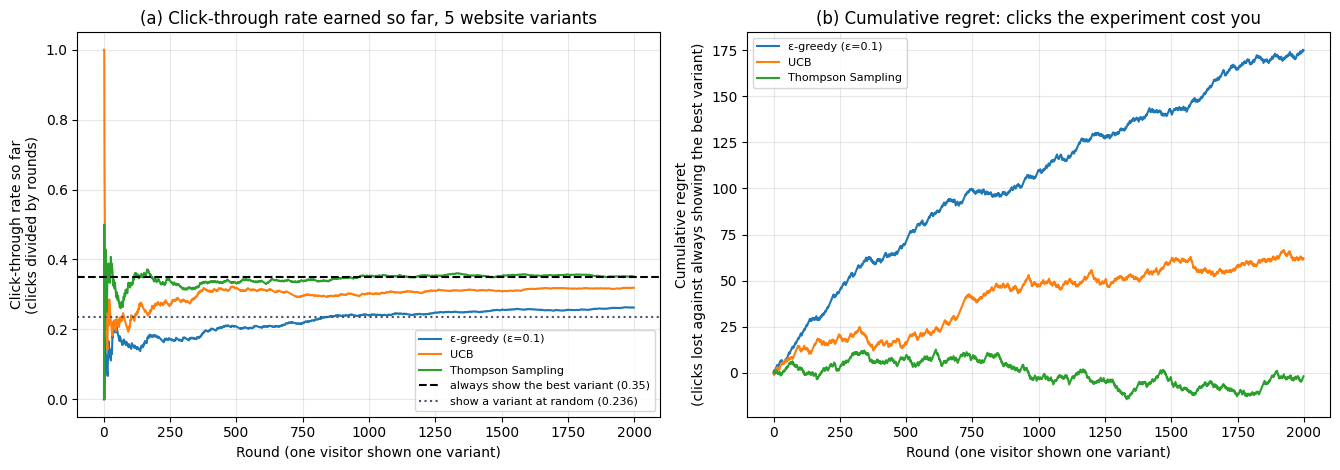


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
# Save a value in a name so the next lines can read it.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
# Another assignment—same idea: store a value for the lines below.
N_ARMS   = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 2000
# Another assignment—same idea: store a value for the lines below.
BEST_RATE = max(TRUE_RATES)

# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        arm = np.random.randint(N_ARMS) if np.random.rand() < eps else np.argmax(totals / (counts + 1e-9))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm] += 1; totals[arm] += r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for arm in range(N_ARMS):
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm] = 1; totals[arm] += r; rewards.append(r)
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ARMS, N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        avg_reward = totals / counts
        # Another assignment—same idea: store a value for the lines below.
        bonus = np.sqrt(2 * np.log(t + 1) / counts)
        # Another assignment—same idea: store a value for the lines below.
        arm = int(np.argmax(avg_reward + bonus))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm] += 1; totals[arm] += r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Save a value in a name so the next lines can read it.
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        samples = np.random.beta(alpha, beta_)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(samples)
        # Another assignment—same idea: store a value for the lines below.
        r = pull(arm)
        # If the condition is True, run the indented block under this line.
        if r: alpha[arm] += 1
        # Else: run this block when none of the if/elif tests above matched.
        else: beta_[arm] += 1
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Save a value in a name so the next lines can read it.
strategies = {
    # Another assignment—same idea: store a value for the lines below.
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'UCB':               ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'Thompson Sampling': thompson(),
# Part of a dict/set literal layout (syntax grouping).
}

# Function `cumavg` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def cumavg(lst): return np.cumsum(lst) / np.arange(1, len(lst) + 1)

# Function `regret_curve` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def regret_curve(lst): return np.cumsum(BEST_RATE - np.array(lst))

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(13.5,4.8))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,1)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumavg(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(BEST_RATE, color='k', linestyle='--', label=f"always show the best variant ({BEST_RATE})")
plt.axhline(np.mean(TRUE_RATES), color='#4a5568', linestyle=':', label=f"show a variant at random ({np.mean(TRUE_RATES):.3f})")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("(a) Click-through rate earned so far, 5 website variants")
plt.xlabel("Round (one visitor shown one variant)")
plt.ylabel("Click-through rate so far\n(clicks divided by rounds)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,2)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(regret_curve(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("(b) Cumulative regret: clicks the experiment cost you")
plt.xlabel("Round (one visitor shown one variant)")
plt.ylabel("Cumulative regret\n(clicks lost against always showing the best variant)")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()
# Show text or numbers in the cell output area under the code.
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")


### 👁️ Read the figure

- **(a) Thompson Sampling reaches the ceiling; the other two do not.** The dashed line is the best variant's true 35% click rate and the dotted line is what showing a random variant earns (23.6%). Thompson's green curve is sitting on the dashed line from about round 700 onwards. UCB settles near 0.31, and ε-greedy is still only around 0.26 at round 2000 — barely above the random-choice line for the first thousand visitors.
- **(b) is the same story in the currency that matters: lost clicks.** Read the **slope**. Thompson's regret curve goes flat (and wobbles slightly below zero — it is measured against the best variant's *expected* rate, so a lucky streak can beat it). UCB's curve is nearly flat by round 1500, having cost about 60 clicks in total. ε-greedy's line is still climbing at about **50 more lost clicks over the final 500 rounds** — roughly 0.1 of a click per visitor, forever, because a fixed ε = 0.1 never stops sending one visitor in ten to a variant it already knows is worse.
- **A flat regret curve is the real definition of "solved".** Not a high reward curve, and certainly not a good-looking first few hundred rounds. Ranked by the total heights at round 2000: Thompson ≈ 0 lost clicks, UCB ≈ 60, ε-greedy ≈ 175.
- **This figure disagrees with the Task 4 figure above, and both are correct.** There, at 500 pulls with `c = 2.0` on arms paying 0.10–0.30, UCB *lost* to ε-greedy. Here, with 2000 rounds and the standard √(2 ln t / n) bonus, it wins comfortably. "UCB beats ε-greedy" is not a fact about the algorithms; it is a claim about a horizon, a set of arm gaps, and a constant.
- **What is real and what is simulated.** The click rates were chosen by us and hidden from the algorithms — that is the only way to grade whether a method found the best variant, which you can never check on live traffic. The randomness is genuine: every round draws one visitor who clicks or does not. One seed is fixed (`np.random.seed(42)`), so this exact picture reproduces; unlike the Task 4 figure, it is a **single run**, so read its rankings as indicative rather than measured.


In [7]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.
"""))


## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can reason about exploration choices and justify them instead of memorizing method names.

**If students remember one idea:** The goal is not to list strategies, but to defend when and why a strategy fits a task.

**Quick check before moving on:**
- Can you explain why your chosen exploration method suits the scenario?
- Can you compare two methods in terms of risk, uncertainty, and data efficiency?

**Bridge to the next step:** After this exercise, students are ready to examine real applications and advanced RL structures in Unit 5.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=10 | term=True | trunc=False


objc[57058]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112288138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1127849c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[57058]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112288188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112784a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[57058]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x112287c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x112784a68). T

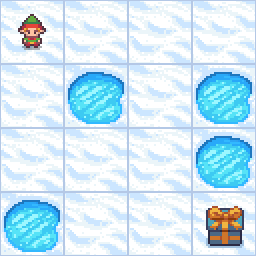

In [8]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
